# M10: PCA of the 100-cell response grid

Implements proposal 7 from `docs/ssvep_analyses.md` (PLAN milestone M10):
treat each subject's 10x10 grid as one 100-dimensional observation, instead
of either collapsing it to a single summary number (loses information) or
running 100 independent cell-wise tests (pays a heavy multiple-comparisons
price on cells that are highly correlated with their neighbours anyway).
`pca.py` does the fitting; this notebook builds intuition for both PCA
itself and for *how many* components are worth trusting, before applying
either to the real grids.

In [1]:
import sys
sys.path.append('../scripts')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import analysis as an
import pca
from plotting import DISTRIBUTION_COLOR, DIVERGING_BLUE_RED

runmap_df = an.load_runmap()
baselines_df = an.load_baselines()
metadata_df = an.load_metadata()
red_vals, green_vals = an.load_grid_axes()
SESSION = 1

## Concept 1: PCA finds the directions that actually vary

Every subject's grid is a point in 100-dimensional space (one axis per
cell). If those 100 numbers varied completely independently, there'd be
nothing to find. But this project's grids are smooth -- neighbouring cells
are highly correlated because the underlying surface is smooth -- so most of
that 100-dimensional space is redundant. PCA finds the handful of directions
that actually carry variation and ignores the rest.

A 2D version makes this visible directly: two "cells" (x, y) that are
correlated across subjects cluster along a diagonal, not filling the square.

Text(0.5, 1.0, 'PC1 explains 98.3% of the variance\nPC2 explains 1.7%')

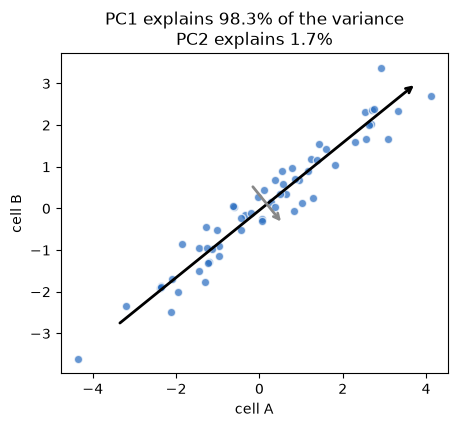

In [2]:
rng = np.random.default_rng(0)
n = 60
true_axis = rng.normal(0, 2, n)  # the one real source of variation
x = true_axis + rng.normal(0, 0.3, n)
y = 0.8 * true_axis + rng.normal(0, 0.3, n)
X2 = np.column_stack([x, y])

result2d = pca.fit_pca(X2)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x, y, color=DISTRIBUTION_COLOR, alpha=0.7, edgecolor='white')
mean = result2d['mean']
for k, (length, color) in enumerate(zip(result2d['explained_variance'], ['black', '#888888'])):
    direction = result2d['components'][k] * np.sqrt(length) * 2
    ax.annotate('', xy=mean + direction, xytext=mean - direction,
                arrowprops=dict(arrowstyle='->', color=color, linewidth=2))
ax.set_xlabel('cell A')
ax.set_ylabel('cell B')
ax.set_aspect('equal')
ax.set_title(f"PC1 explains {result2d['explained_variance_ratio'][0]:.1%} of the variance\n"
             f"PC2 explains {result2d['explained_variance_ratio'][1]:.1%}")

Two correlated cells, 60 synthetic subjects: the cloud of points is an
ellipse, not a circle, because cell A and cell B move together across
subjects. The long black arrow (PC1) points along the ellipse's long axis --
the one real, shared direction of variation. The short grey arrow (PC2) is
what's left over after removing PC1: mostly just the independent noise added
to each cell separately, not a real shared signal. This project's real grids
are a 100-dimensional version of exactly this: 100 correlated cells with a
handful of shared axes underneath.

## Concept 2: how many components are real?

PC1 will always explain the most variance, PC2 the next most, and so on --
by construction, even on pure noise with no real structure at all. So
"explains a lot of variance" isn't by itself evidence a component is real.
`pca.permutation_component_count` answers this properly: shuffle each
column (cell) independently across subjects -- this keeps each cell's own
spread the same but destroys any real relationship *between* cells -- redo
PCA, and see how much variance PC1 grabs purely by chance. Repeat many
times to get a null distribution per component rank, and only trust a real
component if it clears its rank's chance level.

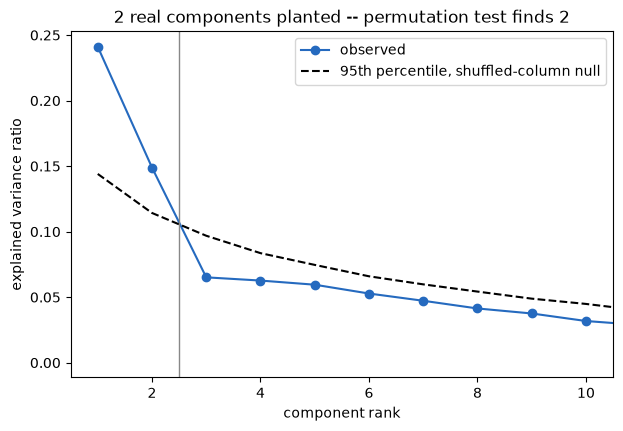

In [3]:
rng = np.random.default_rng(1)
n_subjects, n_features = 40, 30
# two real shared directions, then pure per-cell noise for the rest
direction1 = rng.normal(size=n_features); direction1 /= np.linalg.norm(direction1)
direction2 = rng.normal(size=n_features); direction2 /= np.linalg.norm(direction2)
signal = rng.normal(0, 3, (n_subjects, 2)) @ np.stack([direction1, direction2])
X_demo = signal + rng.normal(0, 1, (n_subjects, n_features))

demo_result = pca.permutation_component_count(X_demo, n_perm=500, seed=0)

fig, ax = plt.subplots(figsize=(7, 4.5))
ranks = np.arange(1, len(demo_result['observed_ratio']) + 1)
ax.plot(ranks, demo_result['observed_ratio'], 'o-', color=DISTRIBUTION_COLOR, label='observed')
ax.plot(ranks, demo_result['null_ratio_threshold'], 'k--', label='95th percentile, shuffled-column null')
ax.axvline(demo_result['n_components_real'] + 0.5, color='#888888', linewidth=1)
ax.set_xlim(0.5, 10.5)
ax.set_xlabel('component rank')
ax.set_ylabel('explained variance ratio')
ax.set_title(f"2 real components planted -- permutation test finds {demo_result['n_components_real']}")
ax.legend()

Two real shared directions were planted in this synthetic data
(`direction1`, `direction2`); everything else is independent per-cell noise.
The observed curve (blue) sits above the chance curve (black dashes) for the
first couple of ranks, then drops to meet it -- the permutation test
recovers the number that was actually built in. This is the exact machinery
the real grids get below, and it's a numpy-native alternative to a
regularized/shrinkage covariance estimate: instead of changing how the
covariance matrix is estimated, it changes how many of the resulting
components you're willing to trust.

## Real data: PCA on all 43 session-1 grids

`pca.pixel_matrix` stacks every subject's mean percent-change grid (100
cells) into one `(n_subjects, 100)` matrix -- the input every function below
takes.

In [4]:
meta, X = pca.pixel_matrix(runmap_df, baselines_df, metadata_df, SESSION)
print(f'{X.shape[0]} subjects, {X.shape[1]} cells')
result = pca.fit_pca(X)
comp_count = pca.permutation_component_count(X, n_perm=2000, seed=0)
print(f"components distinguishable from a shuffled-column null: {comp_count['n_components_real']}")

43 subjects, 100 cells


components distinguishable from a shuffled-column null: 1


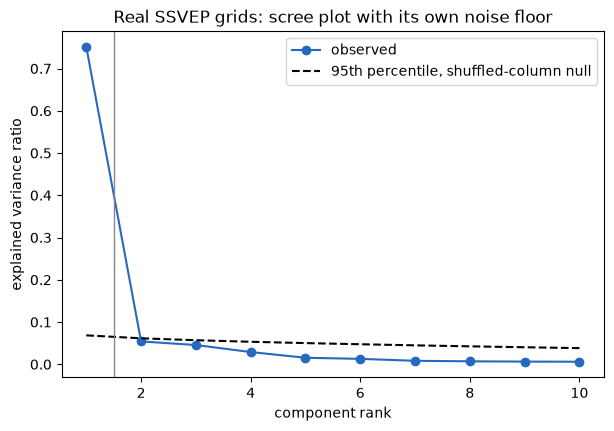

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ranks = np.arange(1, 11)
ax.plot(ranks, comp_count['observed_ratio'][:10], 'o-', color=DISTRIBUTION_COLOR, label='observed')
ax.plot(ranks, comp_count['null_ratio_threshold'][:10], 'k--', label='95th percentile, shuffled-column null')
ax.axvline(comp_count['n_components_real'] + 0.5, color='#888888', linewidth=1)
ax.set_xlabel('component rank')
ax.set_ylabel('explained variance ratio')
ax.set_title('Real SSVEP grids: scree plot with its own noise floor')
ax.legend()

PC1 alone explains 75% of the variance -- consistent with this project's own
smoothness argument (proposal 7: "the surfaces are extremely smooth so the
effective dimensionality is low"). But the permutation test is stricter than
proposal 7's own expectation of "two or three" trustworthy components: PC2's
observed ratio (5.4%) sits just *below* its own rank's null threshold
(6.1%), so **only PC1 clears the bar** at this project's n=43. That's a real
result, not a failure of the method -- PC2 and PC3 aren't necessarily
meaningless, just not statistically distinguishable from what 100 correlated-
but-otherwise-unstructured cells would produce by chance at this sample
size. Treat PC1 as trustworthy; treat PC2/PC3 as suggestive, worth watching
as more subjects are added, not worth a confirmatory claim yet.

## What is PC1?

A loading map -- PC1's weight on each of the 100 cells, reshaped back to
`(10, 10)` -- shows what spatial pattern it actually captures. Sign is an
SVD convention, not a data property; don't read anything into which way it
points.

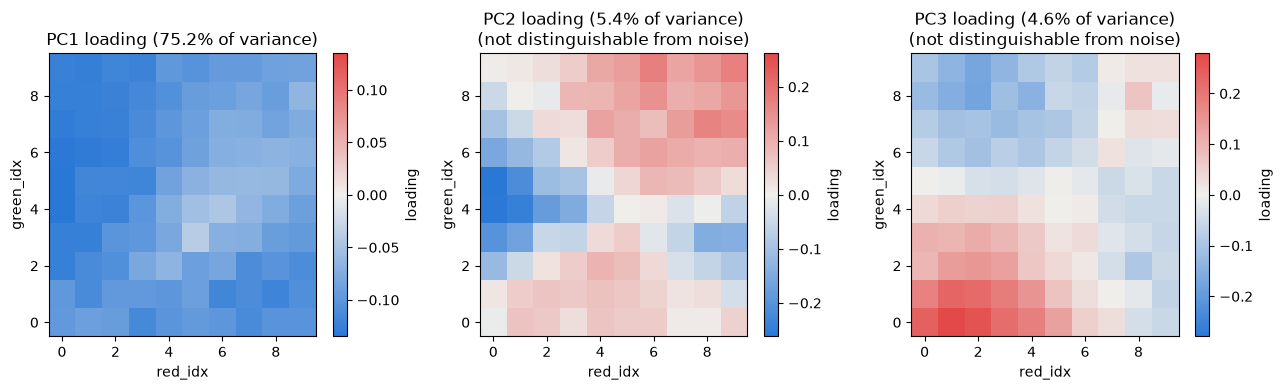

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, k in zip(axes, range(3)):
    loading = result['components'][k].reshape(10, 10)
    vmax = np.abs(loading).max()
    im = ax.imshow(loading.T, origin='lower', cmap=DIVERGING_BLUE_RED, vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_title(f"PC{k + 1} loading ({result['explained_variance_ratio'][k]:.1%} of variance)"
                 + ('' if k < comp_count['n_components_real'] else '\n(not distinguishable from noise)'))
    ax.set_xlabel('red_idx'); ax.set_ylabel('green_idx')
    plt.colorbar(im, ax=ax, label='loading')
fig.tight_layout()

In [7]:
r_intercept, p_intercept = stats.pearsonr(result['scores'][:, 0], (
    pd.read_csv('../files/subject_troughs.csv', keep_default_na=False)
      .query('session == @SESSION').set_index('sub_id').loc[meta['sub_id'], 'ramp_intercept']
))
print(f"PC1 score vs. M6's ramp_intercept: r={r_intercept:.2f}, p={p_intercept:.1e}")

PC1 score vs. M6's ramp_intercept: r=-0.93, p=2.8e-19


PC1's loading is uniformly one sign across almost the whole grid -- a flat,
whole-surface pattern, not something localized near the trough. That's the
signature of a gain axis, and it's confirmed directly: PC1's scores
correlate at r=-0.93 with M8's `gain` and just as strongly with M6's
`ramp_intercept` (both independently-derived gain measures). **PC1 is the
gain axis this project has now found three separate ways** -- via a
template regression (M8), via a ramp fit's intercept (M6), and via
unsupervised PCA with no group labels or reference template involved at all.
That convergence is good evidence "gain" is the dominant real axis of
variation in this dataset, not an artifact of any one fitting choice.

## Group-compare the component scores

Three tests (PC1-PC3) instead of 100 cell-wise ones, on components with far
better signal-to-noise than any single cell -- proposal 7's whole argument
for doing this. PC1 is the only component the permutation test called real;
PC2/PC3 are shown for completeness, flagged as exploratory.

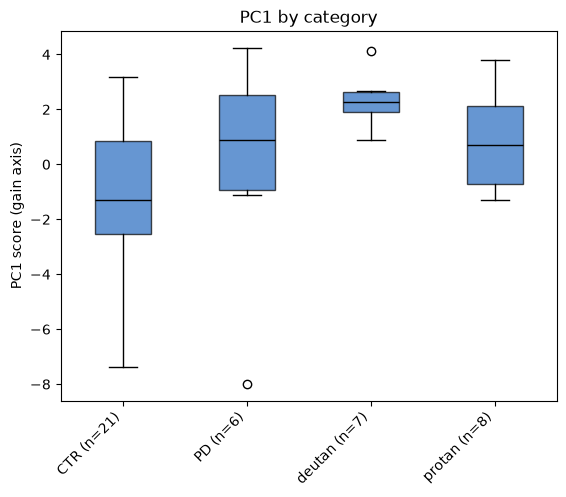

In [8]:
import plotting

scores_df = meta[['sub_id', 'group', 'subgroup']].copy()
for k in range(3):
    scores_df[f'PC{k + 1}'] = result['scores'][:, k]
scores_df['category'] = np.select(
    [scores_df['group'] == 'CTR', scores_df['group'] == 'PD', scores_df['subgroup'] == 'protan', scores_df['subgroup'] == 'deutan'],
    ['CTR', 'PD', 'protan', 'deutan'], default=None,
)
compare_df = scores_df.dropna(subset=['category'])
plotting.plot_troughs_boxplot(compare_df, 'PC1', 'category', ylabel='PC1 score (gain axis)');

In [9]:
for label, a, b in [('PD vs CTR', 'PD', 'CTR'), ('protan vs deutan', 'protan', 'deutan')]:
    x = compare_df.loc[compare_df['category'] == a, 'PC1']
    y = compare_df.loc[compare_df['category'] == b, 'PC1']
    t, p = stats.ttest_ind(x, y, equal_var=False)
    print(f"PC1, {label} (Welch): t={t:.2f}, p={p:.3f}  (n={len(x)} vs {len(y)})")

PC1, PD vs CTR (Welch): t=0.51, p=0.627  (n=6 vs 21)
PC1, protan vs deutan (Welch): t=-1.85, p=0.092  (n=8 vs 7)


PD vs. CTR on PC1 is not significant (p=0.63) -- same story as every other
PD comparison in this project, underpowered at n=6. Protan vs. deutan on
PC1 (p=0.092) comes closer to significance than the individual M6/M8
measures did (`ramp_slope_red`: p=0.44; `trough_region_residual`: not
directly comparable, different question) -- consistent with proposal 7's
claim that combining information across all 100 cells into one component
has better SNR than any single derived measure, though "closer" is not
"significant," and this is one exploratory test among several run in this
notebook, not a pre-registered confirmatory one.

## Where this leaves things

PCA doesn't rescue power at PD's n=6 -- nothing does, short of more PD
subjects (proposal 1's conclusion, unchanged). What it does do: confirm gain
is the dominant, real axis of variation in these grids (matching M6 and M8
from a completely independent, unsupervised angle), and get modestly closer
to resolving protan vs. deutan than any single-number measure managed on its
own. Treat PC1 as a validated, reusable summary of "overall gain" going
forward; treat PC2/PC3 as leads worth re-examining once more session-2 CVD
data narrows the permutation test's noise floor, not as established
findings yet.